In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import h5py
from sklearn.decomposition import PCA
from getdist import MCSamples, plots
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (3.5, 2.5)

In [113]:
path='/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'

nz = h5py.File(f'{path}/roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5','r')
z = np.array(nz['zbinsc'])

# Global parameters
Nz = 46 #len(z)
Nt = 9 # tomo bins
Nd = Nz*Nt # 414
r = 5000 # hundreds/thousands out of 1M realizations

In [114]:
# A hundred random integers between 1 and 1M
np.random.seed(42)
sims_indexes = np.random.randint(1, 10**6 + 1, size=r)
tot = len(sims_indexes)

rows = []

for j in range(tot):
    #print(f"Normalizing n(z) # {j}")
    row = []
    for i in range(9):
        normalized = nz[f'bin{i}'][j] / np.trapz(y=nz[f'bin{i}'][j], x=z)
        row.append(normalized)
    rows.append(np.hstack(row))

n = np.vstack(rows)
nbar = np.mean(n,axis=0)
ndiff = n - nbar
Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1)

# Unweighted PCA

In [115]:
def pcs(Cn,method='eig'):
    #Cn = np.load(f'{path}/codes/Cn_roman_sc1bd4.npy') #TODO: path changed
    Cn = 0.5*(Cn + Cn.T)
    if method == 'eig':
        eigvals, eigvecs = np.linalg.eig(Cn)
    elif method == 'eigh':
        eigvals, eigvecs = np.linalg.eigh(Cn)
    elif method == 'svd':    
        U, S, VT = np.linalg.svd(Cn)
        eigvecs, eigvals = U,S
    elif method == 'sklearn':
        pca = PCA()
        pca.fit(Cn)
        eigvecs, eigvals = pca.components_, pca.singular_values_
        explained_variance = pca.explained_variance_
        explained_variance_ratio = pca.explained_variance_ratio_
    ######
    if method != 'sklearn':
        eigvecs = np.real(eigvecs)
        eigvals = np.real(eigvals)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]
        eigvecs = eigvecs[:, : Nd]
        eigvals = eigvals[: Nd]
        eigvals = np.maximum(0,eigvals)
        return eigvecs, eigvals
    elif method == 'sklearn':
        return eigvecs, eigvals, explained_variance,explained_variance_ratio 

## The principal components are the same, except for a possible sign flip.  
Here we test 4 different methods to obtain the PCs:   1 - linalg.eig,  2 - linagl.eigh,  3 - linalg.svd,  4 - scikit learn

<Figure size 350x250 with 0 Axes>

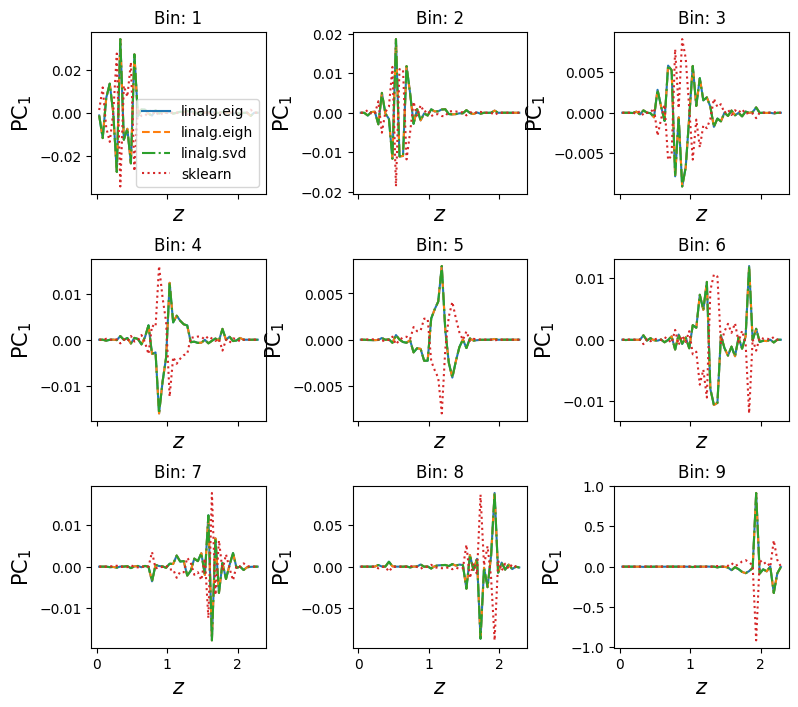

In [116]:
eig_vecs, eig_vals = pcs(Cn,'eig')
eigh_vecs, eigh_vals = pcs(Cn,'eigh')
svd_vecs, svd_vals = pcs(Cn,'svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = pcs(Cn,'sklearn')

plt.figure()
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=False,figsize=(9, 8),
                        gridspec_kw={'wspace':0.5, 'hspace':0.4})
pci = 1
ij = [(i,j) for i in range(nrows) for j in range(ncols)]
for k in range(Nt):
    i,j = ij[k][0],ij[k][1]
    axes[i,j].plot(z,eig_vecs[Nz*k:Nz*(k+1):,pci],ls='-',label='linalg.eig')
    axes[i,j].plot(z,eigh_vecs[Nz*k:Nz*(k+1):,pci],ls='--',label='linalg.eigh')
    axes[i,j].plot(z,svd_vecs[Nz*k:Nz*(k+1):,pci],ls='-.',label='linalg.svd')
    axes[i,j].plot(z,-skl_vecs.T[Nz*k:Nz*(k+1):,pci],ls=':',label='sklearn') # here we flip the PC from scikit learn
    axes[i,j].set_ylabel(rf'PC$_{{{pci}}}$',fontsize=15)
    axes[i,j].set_title(f'Bin: {k+1}')
    axes[i,j].set_xlabel(r'$z$',fontsize=15)

axes[0,0].legend(loc='lower right')

## The singular values are the same.  
Here we test 4 different methods to obtain the singular values:   1 - linalg.eig,  2 - linagl.eigh,  3 - linalg.svd,  4 - scikit learn

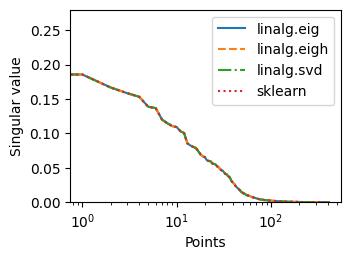

In [117]:
Ms = list(range(Nd))
plt.figure()
plt.plot(Ms,eig_vals,ls='-',label='linalg.eig')
plt.plot(Ms,eigh_vals,ls='--',label='linalg.eigh')
plt.plot(Ms,svd_vals,ls='-.',label='linalg.svd')
plt.plot(Ms,skl_vals,ls=':',label='sklearn')
plt.xscale('log')
plt.ylim(0,0.28)
plt.xlabel('Points')
plt.ylabel('Singular value')
plt.legend(loc='best');

## Lets plot how the PCs's amplitudes are distributed  
The amplitudes $\alpha_i$'s are just the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

nEig:  414
Removed no burn in


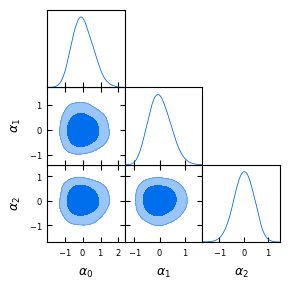

In [118]:
alphas = ndiff @ eigh_vecs
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]
chains = MCSamples(samples=alphas,names=names,labels=labels)

g = plots.get_subplot_plotter(subplot_size=1)
g.triangle_plot(chains,["alpha%s" %i for i in range(3)],filled=True)

## Lets check the function that forward the modified nz to CoCoA  
More specifically, to _cosmolike_prototype_interface.py.

In [119]:
def forward_pca(nz_fid,params_values,survey,photoz_pc_file,npc):
    
    if npc == 0:
        return nz_fid

    elif npc > 0:
        U = photoz_pc_file[:,:npc] # Here is not a file, but in CoCoA is. We keep the notation.
        alphas_vals = np.array([params_values.get(survey+"_alpha_"+str(i+1)) for i in range(npc)])
        
        correction = (alphas_vals * U).sum(axis=1)

        s = nz_fid[:,1:].shape # (46,9)
        z = nz_fid[:,0]

        nz_model = nz_fid[:,1:].T.flatten() + correction # |nz_model| ~ 1 for npc << 414 and |alpha| ~< 1.
        nz_model = nz_model.reshape(s[::-1]).T
        nz_model = np.column_stack((z,nz_model))

        return nz_model

/tmp/ipykernel_617999/2484394601.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[npc].legend(loc='best')


<Figure size 350x250 with 0 Axes>

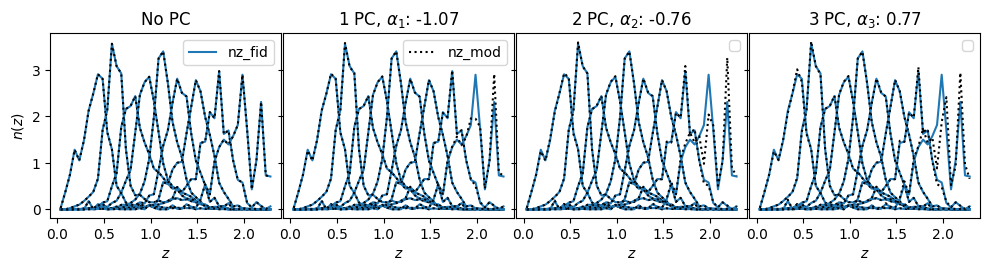

In [120]:
# Lets assume the amplitudes are drawn a normal distribution
seed = 40 # If the seed is turned off, the plot below will be different.
rng = np.random.default_rng(seed)
dist = norm(loc=0, scale=1)
alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)

alphas_r_dict = {f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)}

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) #(46,9) -> (46,10)

plt.figure()
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True,figsize=(12, 2.4),
                        gridspec_kw={'wspace':0.01, 'hspace':0.0})

for npc in range(ncols):
    for k in range(Nt):
        nz_mod = forward_pca(nz_fid,alphas_r_dict,'roman',eigh_vecs,npc) # Must provide nz in the shape (46,1+9)
        axes[npc].plot(z,nz_fid[:,k+1],'C0', label='nz_fid' if npc==0 and k==0 else None)
        axes[npc].plot(z,nz_mod[:,k+1],ls=':',c='k', label='nz_mod' if npc==1 and k==0 else None)
        if npc == 0:
            axes[npc].set_title(f'No PC')
        else:    
            axes[npc].set_title(rf'{npc} PC, $\alpha_{{{npc}}}$: {alphas_r_dict[f"roman_alpha_{npc+1}"]:.2f}')
        axes[npc].set_xlabel(r'$z$')
        axes[0].set_ylabel(r'$n(z)$')
        axes[npc].legend(loc='best')

$\hat{\mathbf{n}}^{r_*}(z)=\bar{\mathbf{n}}^r(z) +\sum_{i=1}^Mu^{r_*}_i\mathbf{U}_i(z)$

In [121]:
alphas_r_dict2 = []
for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

In [130]:
seeds, alphas_r_dict, dist = range(r), [], norm(loc=0, scale=1) # 1 seed for each realization r
alphas_r_dict2 = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)
    alphas_r_dict.append({f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)})
alphas_r_dict = np.stack(alphas_r_dict) # (r,)

for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) # (46,9) -> (46,10)
npc = 3
nzr_mod = []
for ri in range(r):
    x = forward_pca(nz_fid,alphas_r_dict2[ri],'roman',eigh_vecs,npc) # Must provide nz in the shape (46,1+9)
    nzr_mod.append(x[:,1:])
nzr_mod = np.stack(nzr_mod) # (r, 46, 10)
nzr_mod_new = nzr_mod[:,:,:1].transpose(0, 2, 1) #(r, 1, 46)

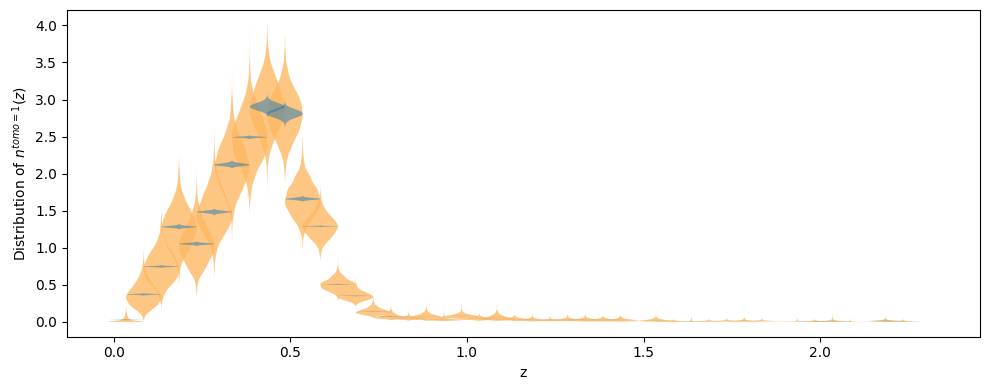

In [131]:
def distribution_violinplot():
    plt.figure(figsize=(10, 4))
    
    nzs = f'{path}roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5'
    nzs = h5py.File(nzs,'r') 
    zbins = np.array(nzs['zbinsc'])
    row=[]
    for j in range(r):
        normalized = nz[f'bin0'][j] / np.trapz(y=nz[f'bin0'][j], x=z)
        row.append(normalized)
    nzs = np.stack(row)
    nzs = np.expand_dims(nzs, axis=1)
    # nzs = np.stack([nzs[f'bin0'][:100,:]], axis=1) #(r, 1, 46)
    v1=plt.violinplot(nzs[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v1['bodies']:
        body.set_facecolor('#FDB863')
        body.set_alpha(0.8)

    v2=plt.violinplot(nzr_mod_new[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v2['bodies']:
        body.set_facecolor('C0')
        body.set_alpha(0.5)
    plt.xlabel(r'$\mathrm{z}$')
    plt.ylabel(r'$\text{Distribution of } n^{tomo=1}(z)$')
    plt.tight_layout()
    return None
distribution_violinplot()

# Weighted PCA